# IQR


In [1]:
import numpy as np

In [2]:
def detect_outliers(data, k=1.5):

    # sort data
    data.sort()

    arr = np.array(data, dtype=float)

    # Q1 & Q3
    Q1 = np.percentile(arr, 25, method='linear')
    Q3 = np.percentile(arr, 75, method='linear')

    # IQR
    IQR = Q3-Q1

    # Lower Fence & Upper Fence
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    mask = (arr >= lower) & (arr <= upper) # to remove outliers
    outliers_mask = ~mask # to extract outlier

    return {
        "Q1" : float(Q1),
        "Q3" : float(Q3),
        "IQR" : float(IQR),
        "lower_fence" : float(lower),
        "upper_fence" : float(upper),
        "outliers" : arr[outliers_mask].tolist(),
        'clean_data' : arr[mask].tolist()
    }

# lower = 20
# upper = 90
# (value > 20) & (value < 90):
# False, False, True, ..... False, False --> mask

In [3]:
student_score = [10, 12, 45, 34, 20, 33, 35, 40, 55, 44, 48, 53, 90, 98]
print(detect_outliers(student_score))

{'Q1': 33.25, 'Q3': 51.75, 'IQR': 18.5, 'lower_fence': 5.5, 'upper_fence': 79.5, 'outliers': [90.0, 98.0], 'clean_data': [10.0, 12.0, 20.0, 33.0, 34.0, 35.0, 40.0, 44.0, 45.0, 48.0, 53.0, 55.0]}


# Skewness



  What is Skewness?

Skewness tells us whether our data is balanced around the center or stretched more toward one side.

Think of a group of people's salaries.

If most people earn around ₹30,000–₹50,000, but a few people earn ₹5 lakh, those very large salaries pull the data toward the right.

That is right skewness.

1. Symmetric data — No skew

Imagine:

        █
      █ █ █
    █ █ █ █ █
  █ █ █ █ █ █ █
-------------------->

The left and right sides are roughly balanced.

Example:

10, 20, 30, 40, 50

Here:

Mean ≈ Median

So skewness is approximately:

$$ \boxed{0} $$
2. Right Skew / Positive Skewness

Most values are on the left, but there are a few very large values on the right.

Example:

10, 12, 13, 14, 15, 16, 100

Visually:

███████████████████
                   \
                    \
                     \________

The tail goes toward the right.

Therefore:

$$ \boxed{\text{Right Skewed = Positive Skew}} $$
What happens to mean?

The value 100 is very large.

It pulls the mean toward the right:

Median      Mean
  ↓           ↓
 14          25

So generally:

$$ \boxed{\text{Mean > Median}} $$
Easy memory trick

Right tail → Mean gets pulled Right

3. Left Skew / Negative Skewness

Now imagine most values are large, but there are a few very small values.

Example:

1, 80, 82, 83, 84, 85, 86

The tail goes toward the left.

________
       /
      /
████████████████████

Therefore:

$$ \boxed{\text{Left Skewed = Negative Skew}} $$

The small value 1 pulls the mean toward the left.

Generally:

$$ \boxed{\text{Mean < Median}} $$
Easy memory trick

Left tail → Mean gets pulled Left

⭐ The most important table
Distribution	Tail	Mean vs Median	Skewness
Symmetric	Neither side	Mean ≈ Median	≈ 0
Right skewed	Right	Mean > Median	Positive
Left skewed	Left	Mean < Median	Negative
🧠 Super easy way to remember

Don't remember positive = right by itself.

Remember:

The sign tells you which direction the tail is pointing.

Positive skew  → Right tail →
Negative skew  ← Left tail
Why does the mean move?

This is the key concept.

Consider:

10, 20, 20, 20, 30

Mean:

$$ \frac{10+20+20+20+30}{5}=20 $$

Now replace 30 with 100:

10, 20, 20, 20, 100

Mean becomes:

$$ \frac{10+20+20+20+100}{5}=34 $$

But the median is still:

20

So:

Median = 20
Mean   = 34

The 100 pulled the mean toward the right.

That's why:

$$ \boxed{\text{Right skew → Mean > Median}} $$
🎯 Why is skewness important in Data Science?

Suppose you're looking at:

Salary
House prices
Transaction amounts
Income
Number of purchases

These datasets often have outliers and can be skewed.

If the data is right-skewed:

Mean ❌ may not represent a "typical" value well
Median ✅ may be better

For example:

Salaries:

30K
35K
40K
42K
45K
50K
500K

The average salary gets pulled up by ₹500K.

So you might say:

"The average salary is ₹106K."

But most people actually earn around ₹30K–₹50K.

The median gives a better idea of the typical salary.

🔥 Interview answer

If the interviewer asks:

"What is skewness?"

You can say:

Skewness measures the asymmetry of a distribution. If the tail extends toward the right, it is positively/right skewed and generally Mean > Median. If the tail extends toward the left, it is negatively/left skewed and generally Mean < Median.

One-line memory trick
$$ \boxed{\text{Tail direction = Skew direction}} $$

Right tail → Positive skew → Mean > Median

Left tail → Negative skew → Mean < Median

In [5]:
from scipy.stats import skew
import numpy as np

In [6]:
data = [10, 20, 30, 40, 90]
print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Skewness:", skew(data))

Mean: 38.0
Median: 30.0
Skewness: 1.0391889223704167


In [7]:
data = [-300, 10, 20, 30, 40, 50]
print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Skewness:", skew(data))

Mean: -25.0
Median: 25.0
Skewness: -1.7451457585195216


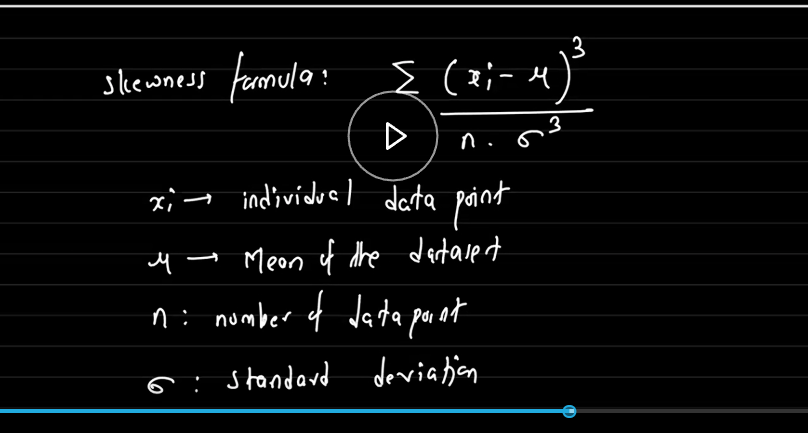

# kurtosis

What is Kurtosis?

Kurtosis tells us about the behavior of the extreme values (tails) in a distribution.

In simple words:

Kurtosis helps us understand how much extreme data/outliers a distribution tends to have.

Think of it as asking:

"Does this dataset have more extreme values than a normal distribution?"

First, understand the "tails"

Look at a distribution:

                 Center
                   ↓
              ███████
           █████████████
        ███████████████████
____██████████████████████████____
    ↑                          ↑
  Left tail                 Right tail

The tails are the areas at the extreme left and extreme right.

Kurtosis mainly focuses on these tails.

There are 3 types of Kurtosis
1. Mesokurtic

This is approximately the normal distribution.

              /\
            /    \
          /        \
        /            \
_______/              \_______

Its kurtosis is:

$$ \boxed{3} $$

But many Data Science libraries report excess kurtosis, where normal distribution =:

$$ \boxed{0} $$

So be careful in interviews.

2. Leptokurtic

This distribution has heavier tails.

That means there is a greater tendency to have extreme values/outliers.

                 /\
                /  \
               /    \
______________/      \______________

The important thing is not simply "the peak is taller."

The important point is:

Heavier tails → more extreme observations.

For excess kurtosis:

$$ \boxed{>0} $$

This is called positive excess kurtosis.

3. Platykurtic

This distribution has lighter/thinner tails.

There are fewer extreme observations compared with a normal distribution.

             ______
           /        \
         /            \
_______/                \_______

For excess kurtosis:

$$ \boxed{<0} $$

This is called negative excess kurtosis.

🧠 Easy way to remember

Think about the tails, not just the height of the curve.

Type	Tails	Extreme values	Excess Kurtosis
Mesokurtic	Normal	Normal	0
Leptokurtic	Heavy	More	> 0
Platykurtic	Light	Fewer	< 0
Memory trick
Leptokurtic  → Heavy tails → More extremes → Positive

Platykurtic  → Light tails → Fewer extremes → Negative
Kurtosis vs Skewness

This is very important for interviews.

Skewness asks:

"Is the distribution pulled toward the left or right?"

Left ←──── Distribution ────→ Right

Skewness = asymmetry
Kurtosis asks:

"How heavy are the tails / how much extreme data is present?"

Extreme ←──── Center ────→ Extreme

Kurtosis = tail/extreme-value behavior

So:

$$ \boxed{\text{Skewness → Asymmetry}} $$ $$ \boxed{\text{Kurtosis → Tail heaviness / extreme values}} $$
Simple real-life example

Imagine two groups of salaries.

Dataset A
30K, 32K, 35K, 36K, 38K, 40K

Values are fairly close together.

Dataset B
30K, 32K, 35K, 36K, 38K, 500K

There is an extreme value:

500K

This kind of extreme observation contributes strongly to the tails and can result in higher kurtosis.

One important correction to common explanations

You may see people say:

"Kurtosis tells you how peaked the distribution is."

This is an oversimplification.

For Data Science interviews, a better answer is:

Kurtosis measures the heaviness of the tails of a distribution and therefore indicates the tendency toward extreme observations.

The tails are more important than simply looking at whether the curve is tall or flat.

Formula

The population kurtosis is commonly written as:

$$ \boxed{ K=\frac{1}{N}\sum_{i=1}^{N} \left(\frac{x_i-\mu}{\sigma}\right)^4 } $$

Why the 4th power?

Because large deviations become very large when raised to the fourth power.

For example:

$$ 2^4=16 $$

but:

$$ 5^4=625 $$

So extreme observations get a very large weight.

That's why kurtosis is sensitive to extreme values.

🎯 Interview answer

If the interviewer asks:

"What is kurtosis?"

You can say:

Kurtosis measures the heaviness of the tails of a distribution and indicates the tendency of the data to contain extreme values or outliers.

And remember:

Skewness → Which direction is the distribution asymmetric?

Kurtosis → How heavy are the tails / how extreme are the values?
⭐ Final cheat sheet
$$ \boxed{\text{Positive Excess Kurtosis → Heavy tails → More extreme values}} $$ $$ \boxed{\text{Zero Excess Kurtosis → Normal-like tails}} $$ $$ \boxed{\text{Negative Excess Kurtosis → Light tails → Fewer extreme values}} $$

One thing to memorize for your interview:

Skewness = asymmetry. Kurtosis = tail heaviness/extreme values.

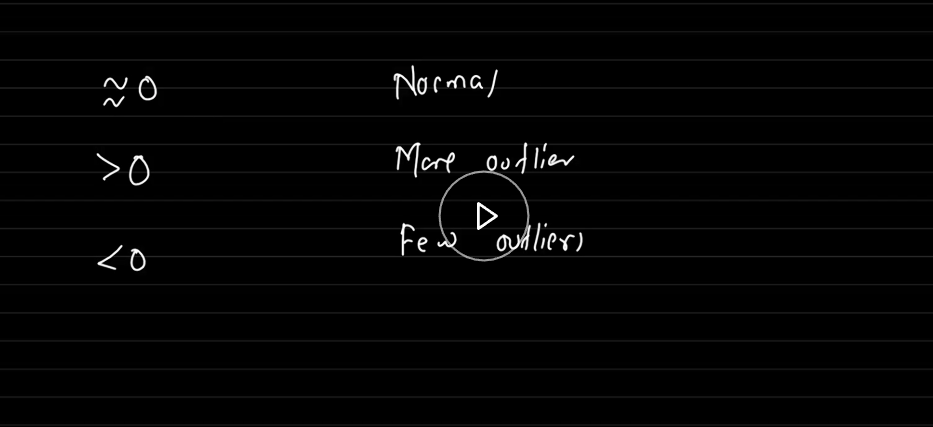

In [9]:
from scipy.stats import kurtosis

In [10]:

data = [10, 20, 30, 40, 1000]

mean = np.mean(data)
std = np.std(data)

skew = np.mean((data - mean)**3) / (std**3)

# Pearson's Kurtosis (Normal distribution = 3.0)
kur = np.mean((data - mean)**4) / (std**4)

# # Excess Kurtosis (Normal distribution = 0.0)
excess_kurt = (np.mean((data - np.mean(data))**4) / (np.std(data)**4)) - 3

print("Skewness : ", skew)

print("Kurtosis : " , kur)
print("Kurtosis : " , excess_kurt)
# kurtosis
print(kurtosis(data)) 
# 3.24 extreme value exist

Skewness :  1.49753670333352
Kurtosis :  3.246716489300164
Kurtosis :  0.2467164893001641
0.24671648930016365
